# Parkinson multimodal staff demo (speech + handwriting + gait)

**Disclaimer:** Research and education only. Not a medical device; not for diagnosis.

This notebook ties **`data/raw/`** (tabular CSVs) and **`notebooks/sample/`** (WAV, image, video) to the same pipeline as **`MultimodalPDNet`**. **Feature counts and CSV paths** come from **`config/multimodal_features.yaml`**. **Tabular CSVs** are used for EDA and training alignment. **Model inference (Steps 5–7)** uses **real-time extraction** from your demo media via `common/audio_processing`, `image_processing`, and `video_processing` — vectors are aligned to the same column order as training (no CSV row substitution, no zero-filled modalities).

**How to run:** **Kernel → Restart & Run All** (or top-to-bottom from setup). You need **all three multimodal CSVs** under `data/raw/` for Steps 1–3, and **WAV + image + video** under `notebooks/sample/` (or example WAVs under `data/examples/speech/`) so **Step 4c** can run real-time extraction before Steps 5–7.

**Contents:** architecture → YAML feature table → data paths → tabular load & EDA → media extractors → model & fusion → classifier & output → saved training metrics & figures.


## System architecture (production vs this notebook)

**Production web app** (conceptually): user auth → uploads (speech **WAV/MP3**, handwriting **JPG**, gait **MP4/OGG**) → validation → feature extraction → model → detection.

**This notebook** starts at **tabular `data/raw/`** and **raw media in `notebooks/sample/`**, then walks the same **model** stages with plots.

### Packages vs diagram (short)

Widths **N_speech / N_hw / N_gait** = lengths of the three lists in **`config/multimodal_features.yaml`** (defaults: 22 / 10 / 10).

| Modality | Size | Implementation (`common/`) |
|----------|------|----------------------------|
| Speech | **N_speech** scalars | **librosa** + **soundfile** + **parselmouth** (Praat) in `audio_processing.py` |
| Handwriting | **N_hw** scalars | **OpenCV** + **PIL** + **scipy** + **skimage** in `image_processing.py` |
| Gait | **N_gait** scalars | **OpenCV** in `video_processing.py` |

### Flow (matches the reference diagram)

```mermaid
flowchart LR
  subgraph ingest [Inputs]
    CSV[data_raw_CSVs]
    Media[notebooks_sample_WAV_JPG_MP4]
  end
  subgraph feat [Feature_extraction]
    A[Librosa_Praat_Nspeech]
    B[OpenCV_skimage_Nhw]
    C[OpenCV_Ngait]
  end
  subgraph enc [SE_ResNet1D_encoders]
    Es[speech_encoder_Ns]
    Eh[handwriting_encoder_Nh]
    Eg[gait_encoder_Ng]
  end
  CSV --> A
  Media --> A
  Media --> B
  Media --> C
  A --> Es
  B --> Eh
  C --> Eg
  Es --> F[AttentionFusion]
  Eh --> F
  Eg --> F
  F --> D[Dense_64_32_1]
  D --> S[Sigmoid]
  S --> Out[Healthy_or_PD]
```


In [21]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

try:
    _ip = get_ipython()
except NameError:
    _ip = None
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "train_dl.py").is_file() and (d / "common").is_dir():
            return d
    raise FileNotFoundError("Could not find repository root.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW = ROOT / "data" / "raw"
EXAMPLES = ROOT / "data" / "examples" / "speech"
MODELS = ROOT / "models"
NOTEBOOK_SAMPLES = ROOT / "notebooks" / "sample"

pd.set_option("display.max_columns", 30)

# Demo media under notebooks/sample/ (flexible filenames; logic lives here, not a separate file).
_IMAGE_EXTS = frozenset({".jpg", ".jpeg", ".png", ".webp"})
_VIDEO_EXTS = frozenset({".mp4", ".avi", ".mov", ".mkv", ".webm"})


def resolve_handwriting_demo_path(dest_dir: Path):
    dest_dir = Path(dest_dir)
    if not dest_dir.is_dir():
        return None
    for name in ("handwriting_demo.jpg", "Handwriting.jpg", "handwriting.jpg"):
        p = dest_dir / name
        if p.is_file():
            return p
    images = sorted(
        p for p in dest_dir.iterdir() if p.is_file() and p.suffix.lower() in _IMAGE_EXTS
    )
    return images[0] if images else None


def resolve_gait_demo_video(dest_dir: Path):
    dest_dir = Path(dest_dir)
    if not dest_dir.is_dir():
        return None
    preferred = dest_dir / "gait_demo.avi"
    if preferred.is_file():
        return preferred
    videos = sorted(
        p for p in dest_dir.iterdir() if p.is_file() and p.suffix.lower() in _VIDEO_EXTS
    )
    return videos[0] if videos else None


def ordered_speech_demo_paths(dest_dir: Path, repo_root: Path):
    dest_dir = Path(dest_dir)
    repo_root = Path(repo_root)
    names = [
        "parkinson_example.wav",
        "healthy_example.wav",
        "speech_hc_figshare.wav",
        "speech_pd_figshare.wav",
        "speech_demo.wav",
    ]
    paths = [dest_dir / name for name in names]
    paths.append(repo_root / "data" / "examples" / "speech" / "healthy_example.wav")
    paths.append(repo_root / "data" / "examples" / "speech" / "parkinson_example.wav")
    return paths


print("ROOT =", ROOT)

FEATURE_SPEC_PATH = ROOT / "config" / "multimodal_features.yaml"
if not FEATURE_SPEC_PATH.is_file():
    raise FileNotFoundError(
        f"Missing feature spec: {FEATURE_SPEC_PATH}\n"
        "Restore config/multimodal_features.yaml from the repository."
    )
with open(FEATURE_SPEC_PATH, encoding="utf-8") as _yf:
    MFC = yaml.safe_load(_yf)
if not isinstance(MFC, dict):
    raise ValueError("multimodal_features.yaml must contain a YAML mapping at the top level.")
for _req in ("speech_features", "handwriting_features", "gait_features", "label_column", "csv_paths"):
    if _req not in MFC:
        raise KeyError(f"multimodal_features.yaml missing required key: {_req!r}")
for _m in ("speech", "handwriting", "gait"):
    if _m not in MFC["csv_paths"]:
        raise KeyError(f"csv_paths missing {_m!r}")
SPEECH_CSV = RAW / MFC["csv_paths"]["speech"]
print(
    "config/multimodal_features.yaml:",
    f"speech={len(MFC['speech_features'])}, handwriting={len(MFC['handwriting_features'])}, gait={len(MFC['gait_features'])}",
)
print("Speech CSV path:", SPEECH_CSV)

from IPython.display import display

# System diagram: see the Mermaid flowchart in the markdown cell above (no bundled PNG).


ROOT = /Users/jenishs/Parkinson
config/multimodal_features.yaml: speech=22, handwriting=10, gait=10
Speech CSV path: /Users/jenishs/Parkinson/data/raw/speech/parkinsons.csv


### Feature columns loaded from CSV (single source of truth)

All tabular columns used for **`MultimodalPDNet`** training are listed in **`config/multimodal_features.yaml`**. `train_dl.py` reads the same file via `data.multimodal_features_config` in **`config/project.yaml`**. The next cell prints every column name with its index (speech, then handwriting, then gait).

In [22]:
_rows = []
for i, name in enumerate(MFC["speech_features"]):
    _rows.append({"modality": "speech", "index": i, "csv_column": name})
for i, name in enumerate(MFC["handwriting_features"]):
    _rows.append({"modality": "handwriting", "index": i, "csv_column": name})
for i, name in enumerate(MFC["gait_features"]):
    _rows.append({"modality": "gait", "index": i, "csv_column": name})
display(pd.DataFrame(_rows))
print(
    "Label column:", repr(MFC["label_column"]),
    "| CSV paths (relative to data/raw):",
    MFC["csv_paths"],
)

,modality,index,csv_column
0,speech,0,MDVP:Fo(Hz)
1,speech,1,MDVP:Fhi(Hz)
2,speech,2,MDVP:Flo(Hz)
3,speech,3,MDVP:Jitter(%)
4,speech,4,MDVP:Jitter(Abs)
5,speech,5,MDVP:RAP
6,speech,6,MDVP:PPQ
7,speech,7,Jitter:DDP
8,speech,8,MDVP:Shimmer
9,speech,9,MDVP:Shimmer(dB)


Label column: 'status' | CSV paths (relative to data/raw): {'speech': 'speech/parkinsons.csv', 'handwriting': 'handwriting/handwriting_data.csv', 'gait': 'gait/gait_data.csv'}


## Data map — `data/raw` and `notebooks/sample`

Tabular training-style data lives under **`data/raw/`**; optional **raw clips** for the same feature extractors as the web app live in **`notebooks/sample/`** (paths resolved by small helpers in the setup code cell).


In [23]:
_cp = MFC["csv_paths"]
paths_check = [
    ("Speech CSV", RAW / _cp["speech"]),
    ("Handwriting CSV", RAW / _cp["handwriting"]),
    ("Gait CSV", RAW / _cp["gait"]),
]
rows = [{"name": n, "path": str(p), "exists": p.is_file()} for n, p in paths_check]
for label, p in [
    ("Speech WAV (resolved)", ordered_speech_demo_paths(NOTEBOOK_SAMPLES, ROOT)[0]),
    ("Handwriting image", resolve_handwriting_demo_path(NOTEBOOK_SAMPLES)),
    ("Gait video", resolve_gait_demo_video(NOTEBOOK_SAMPLES)),
]:
    path_str = str(p) if p is not None else ""
    rows.append({"name": label, "path": path_str, "exists": Path(path_str).is_file() if path_str else False})
display(pd.DataFrame(rows))


,name,path,exists
0,Speech CSV,/Users/jenishs/Parkinson/data/raw/speech/parki...,True
1,Handwriting CSV,/Users/jenishs/Parkinson/data/raw/handwriting/...,True
2,Gait CSV,/Users/jenishs/Parkinson/data/raw/gait/gait_da...,True
3,Speech WAV (resolved),/Users/jenishs/Parkinson/notebooks/sample/park...,True
4,Handwriting image,/Users/jenishs/Parkinson/notebooks/sample/Hand...,True
5,Gait video,/Users/jenishs/Parkinson/notebooks/sample/What...,True


## Step 1 — Load tabular data (all modalities) — **training / EDA only**

- Same loader as **`train_dl.py`**: **`config/multimodal_features.yaml`**. All three CSVs must exist (no zero-filled fallback).
- Used for **class balance, correlations, distributions** below — **not** for the neural forward in Steps 5–7 (that path re-runs extractors on media files).
- **Refresh CSVs:** `python scripts/train_voice_pipeline.py --download-speech` or `bash data/raw/speech/download_speech_csvs.sh`.


Loaded aligned multimodal tabular data (EDA / training contract): (195, 22) (195, 10) (195, 10)
Speech CSV rows: 195 | PD: 147 | Healthy: 48


,quantity,value
0,aligned samples (n),195.0000
1,speech features,22.0000
2,handwriting features,10.0000
3,gait features,10.0000
4,PD count (labels),147.0000
5,Healthy count (labels),48.0000
6,mean HNR (all rows),21.8860
7,std HNR (all rows),4.4258


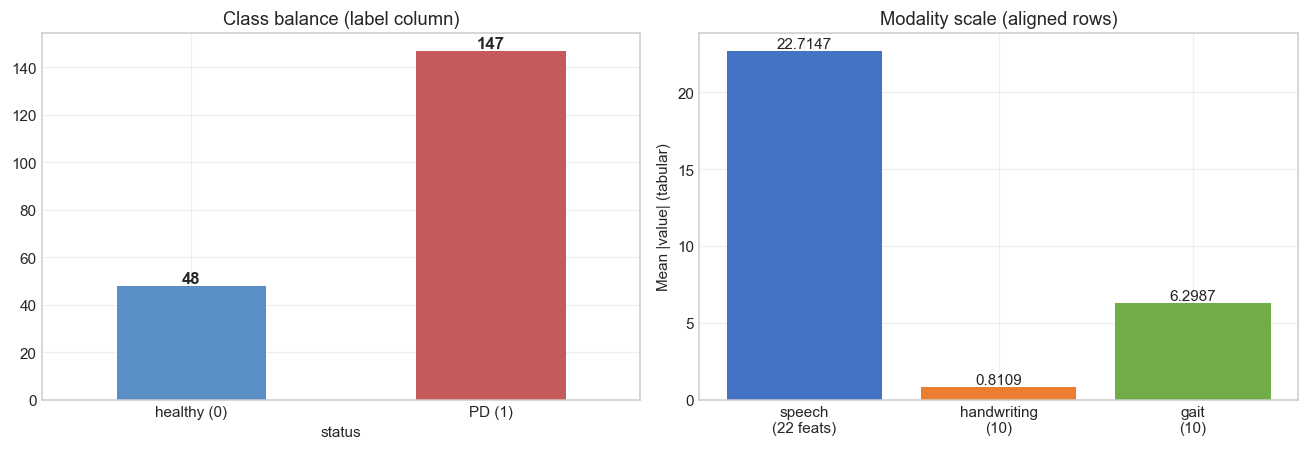

In [24]:
from dl_models.data import (
    GAIT_FEATURE_NAMES,
    HANDWRITING_FEATURE_NAMES,
    SPEECH_FEATURE_NAMES,
    load_all_modalities,
)

speech_X, hw_X, gait_X, y_all = load_all_modalities(
    RAW, feature_spec_path=str(FEATURE_SPEC_PATH),
)
print("Loaded aligned multimodal tabular data (EDA / training contract):", speech_X.shape, hw_X.shape, gait_X.shape)

df_speech = pd.read_csv(SPEECH_CSV)
lc = str(MFC["label_column"])
print(
    "Speech CSV rows:", len(df_speech), "| PD:", int((df_speech[lc] == 1).sum()),
    "| Healthy:", int((df_speech[lc] == 0).sum()),
)

_summary = pd.DataFrame(
    [
        {
            "quantity": "aligned samples (n)",
            "value": len(speech_X),
        },
        {
            "quantity": "speech features",
            "value": speech_X.shape[1],
        },
        {
            "quantity": "handwriting features",
            "value": hw_X.shape[1],
        },
        {
            "quantity": "gait features",
            "value": gait_X.shape[1],
        },
        {
            "quantity": "PD count (labels)",
            "value": int(y_all.sum()),
        },
        {
            "quantity": "Healthy count (labels)",
            "value": int((y_all == 0).sum()),
        },
        {
            "quantity": "mean HNR (all rows)",
            "value": round(float(df_speech["HNR"].mean()), 4),
        },
        {
            "quantity": "std HNR (all rows)",
            "value": round(float(df_speech["HNR"].std()), 4),
        },
    ],
)
display(_summary)

# Mean absolute magnitude by modality (tabular tensors)
_has_hw = np.abs(hw_X).sum() > 1e-9
_has_g = np.abs(gait_X).sum() > 1e-9
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
df_speech[lc].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Class balance (label column)", color=["#5a8fc5", "#c55a5a"],
)
axes[0].set_xticklabels(["healthy (0)", "PD (1)"], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
if _has_hw or _has_g:
    means = [np.mean(np.abs(speech_X)), np.mean(np.abs(hw_X)), np.mean(np.abs(gait_X))]
    labels_m = [
        f"speech\n({speech_X.shape[1]} feats)",
        f"handwriting\n({hw_X.shape[1]})",
        f"gait\n({gait_X.shape[1]})",
    ]
    bars = axes[1].bar(labels_m, means, color=["#4472c4", "#ed7d31", "#70ad47"])
    axes[1].set_ylabel("Mean |value| (tabular)")
    axes[1].set_title("Modality scale (aligned rows)")
    for bar, m in zip(bars, means):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{m:.4f}",
            ha="center", va="bottom", fontsize=10,
        )
else:
    axes[1].text(0.5, 0.5, "Handwriting/gait are zero\n(multimodal CSVs missing)", ha="center", va="center")
    axes[1].set_axis_off()
plt.tight_layout()
plt.show()


### Step 1b — Tabular schema and alignment

Sanity-check shapes after load (same contract as `load_all_modalities` in `dl_models/data/dataset.py`).


In [25]:
n = len(speech_X)
assert speech_X.shape == (n, len(SPEECH_FEATURE_NAMES)), speech_X.shape
assert hw_X.shape == (n, len(HANDWRITING_FEATURE_NAMES)), hw_X.shape
assert gait_X.shape == (n, len(GAIT_FEATURE_NAMES)), gait_X.shape
assert len(y_all) == n, (len(y_all), n)
print(
    "OK: aligned tabular tensors | n =",
    n,
    "| dims =",
    speech_X.shape[1],
    hw_X.shape[1],
    gait_X.shape[1],
)


OK: aligned tabular tensors | n = 195 | dims = 22 10 10


### Step 2a — Speech: **librosa** (+ **Praat** via parselmouth in `extract_speech_features`)

**Librosa** drives waveform / mel plots; **`extract_speech_features`** (same call as **Step 4c**) produces the **N_speech** scalars in **`speech_features`** YAML order. This is live processing from your WAV, not CSV.


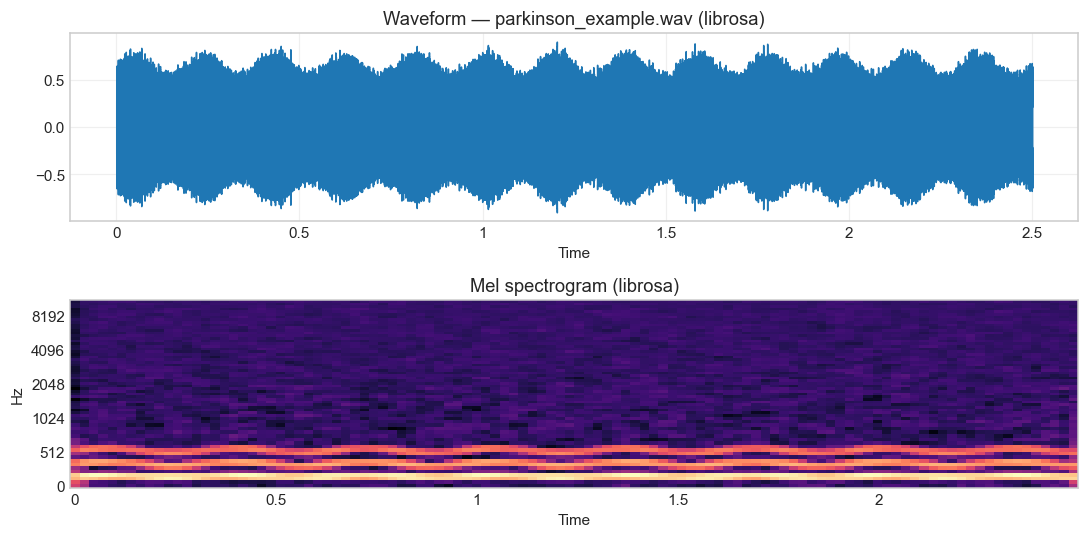

parkinson_example.wav: ZCR=0.03395, RMS=0.37280, centroid_mean=3411.5 Hz


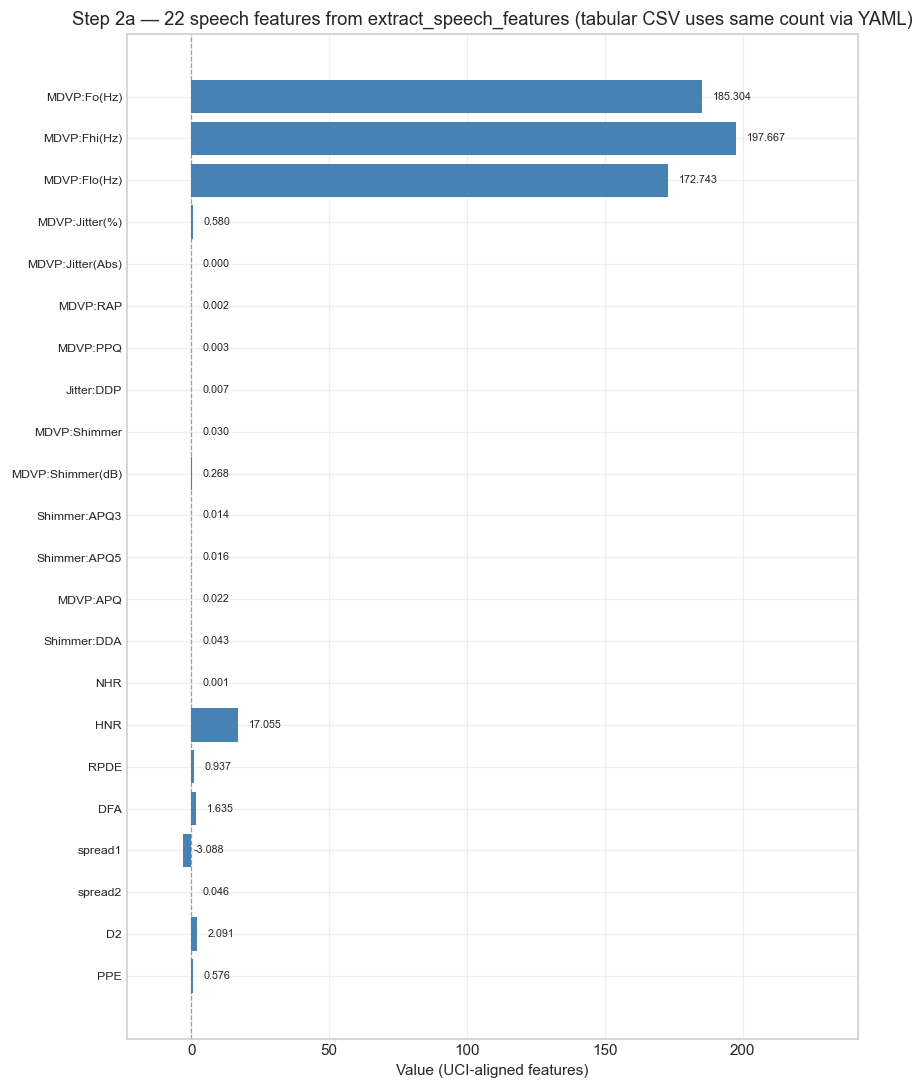

In [26]:
import librosa
import librosa.display

from common.audio_processing import extract_speech_features, get_feature_names

clips = []
speech_paths = ordered_speech_demo_paths(NOTEBOOK_SAMPLES, ROOT)
for p in speech_paths:
    if p.is_file():
        y, sr = librosa.load(str(p), sr=None, mono=True)
        clips.append((p.name, y, sr, str(p)))
        fig, ax = plt.subplots(2, 1, figsize=(10, 5))
        librosa.display.waveshow(y, sr=sr, ax=ax[0])
        ax[0].set_title(f"Waveform — {p.name} (librosa)")
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
        ax[1].set_title("Mel spectrogram (librosa)")
        plt.tight_layout()
        fig.canvas.draw()
        plt.show()
        break
else:
    for path, title in [
        (EXAMPLES / "healthy_example.wav", "healthy_example"),
        (EXAMPLES / "parkinson_example.wav", "parkinson_example"),
    ]:
        if not path.is_file():
            print(f"Missing {path.name} — python scripts/generate_example_speech_wavs.py")
            continue
        y, sr = librosa.load(str(path), sr=None, mono=True)
        clips.append((title, y, sr, str(path)))
        fig, ax = plt.subplots(2, 1, figsize=(10, 5))
        librosa.display.waveshow(y, sr=sr, ax=ax[0])
        ax[0].set_title(f"Waveform — {title}")
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
        ax[1].set_title("Mel spectrogram (librosa)")
        plt.tight_layout()
        fig.canvas.draw()
        plt.show()
        break

if clips:
    title, y, sr, audio_path = clips[0]
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    rms = float(np.mean(librosa.feature.rms(y=y)))
    cent = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    print(f"{title}: ZCR={zcr:.5f}, RMS={rms:.5f}, centroid_mean={cent:.1f} Hz")
    uci = extract_speech_features(audio_path)
    names = get_feature_names()
    vals = [uci[k] for k in names]
    fig, ax = plt.subplots(figsize=(8, 10))
    y_pos = np.arange(len(names))
    bars = ax.barh(y_pos, vals, color="steelblue")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Value (UCI-aligned features)")
    ax.set_title(
        f"Step 2a — {len(names)} speech features from extract_speech_features (tabular CSV uses same count via YAML)",
    )
    ax.invert_yaxis()
    lo, hi = float(min(vals)), float(max(vals))
    span = max(hi - lo, 1e-9)
    ax.set_xlim(lo - 0.1 * span, hi + 0.22 * span)
    ax.axvline(0, color="#888", linewidth=0.8, linestyle="--", zorder=0)
    xr = ax.get_xlim()[1] - ax.get_xlim()[0]
    for bar, v in zip(bars, vals):
        tip = bar.get_x() + bar.get_width()
        ax.text(
            tip + 0.015 * xr,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}",
            va="center",
            ha="left",
            fontsize=7,
        )
    plt.tight_layout()
    fig.canvas.draw()
    plt.show()
else:
    print("No speech WAV loaded.")
    audio_path = None


### Step 2b — Handwriting: **OpenCV** (+ **PIL**, **scipy**, **skimage** in `image_processing.py`)

Live image → **`extract_handwriting_features`** (same as **Step 4c**). Tables use extractor-native names; **Step 4c** remaps to **`handwriting_features`** YAML order for the model.


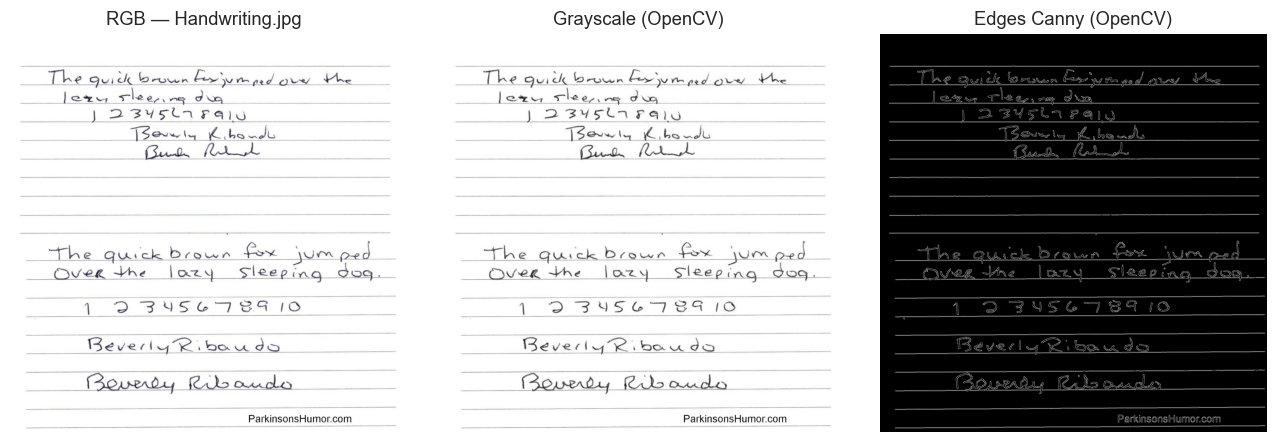

,feature,value
0,mean_pressure,0.299688
1,std_pressure,0.150855
2,mean_velocity,2.850656
3,std_velocity,0.925328
4,mean_acceleration,1.425328
5,pen_up_time,0.400000
6,stroke_length,128.395000
7,writing_tempo,1.100000
8,tremor_frequency,8.000000
9,fluency_score,0.610393


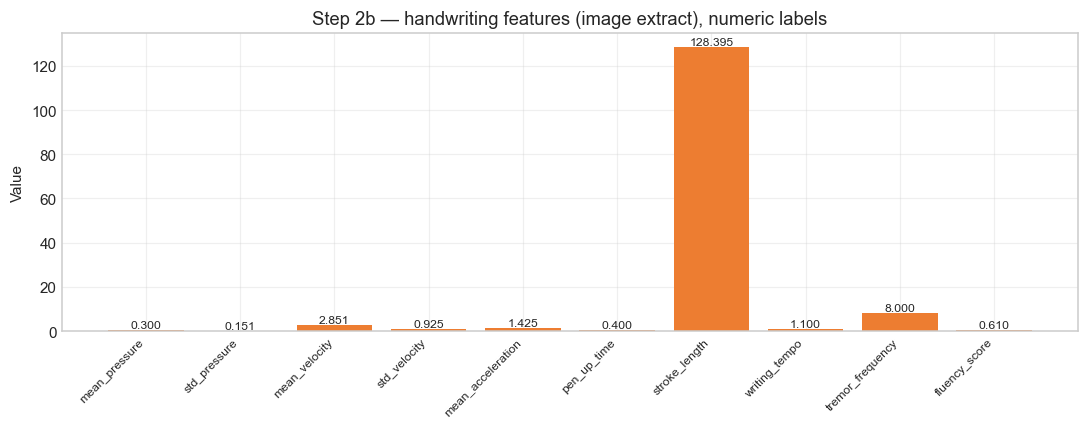

In [27]:
import cv2
import matplotlib.image as mpimg

from common.image_processing import extract_handwriting_features, get_feature_names as hw_image_feature_names

hj = resolve_handwriting_demo_path(NOTEBOOK_SAMPLES)
if hj is not None:
    bgr = cv2.imread(str(hj))
    if bgr is None:
        rgb = mpimg.imread(str(hj))
        if rgb.dtype == np.float32 and rgb.max() <= 1.0:
            rgb = (rgb * 255).astype(np.uint8)
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY) if len(rgb.shape) == 3 else rgb
    else:
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(rgb)
    axes[0].set_title(f"RGB — {hj.name}")
    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Grayscale (OpenCV)")
    axes[2].imshow(edges, cmap="gray")
    axes[2].set_title("Edges Canny (OpenCV)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    hw_dict = extract_handwriting_features(str(hj))
    _hnames = hw_image_feature_names()
    _hvals = [hw_dict[k] for k in _hnames]
    display(pd.DataFrame({"feature": _hnames, "value": _hvals}))
    fig, ax = plt.subplots(figsize=(10, 4))
    xo = np.arange(len(_hnames))
    bars = ax.bar(xo, _hvals, color="#ed7d31")
    ax.set_xticks(xo)
    ax.set_xticklabels(_hnames, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Value")
    ax.set_title("Step 2b — handwriting features (image extract), numeric labels")
    for bar, v in zip(bars, _hvals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    plt.tight_layout()
    plt.show()
else:
    print("No handwriting image in notebooks/sample.")


### Step 2c — Gait: **OpenCV** (`video_processing.py`)

Frame-difference **motion** (same **300**-frame cap as `extract_gait_features`) → **N_gait** features. **`extract_gait_features`** is the same call as **Step 4c** (stdout suppressed there to keep output clean).


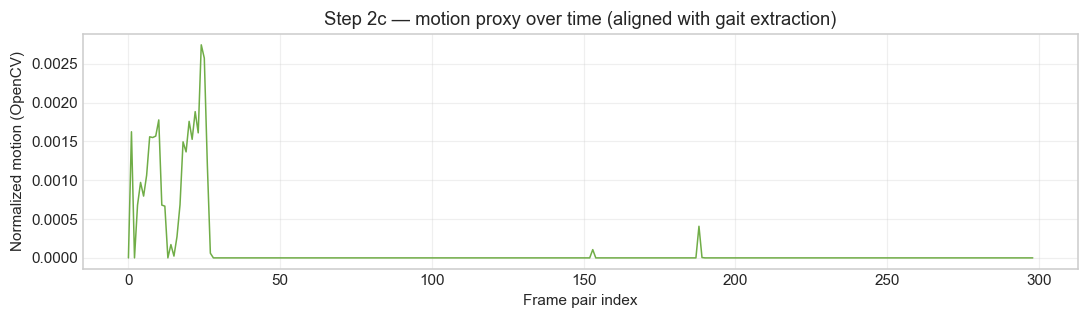

  Motion factor: 0.0001
  Applied LOW motion adjustments
  Brightness variation: 0.31
✓ Extracted gait features from 301 frames (300 motion samples)
  Sample features: stride_interval=1.602, gait_speed=0.070, regularity=0.360



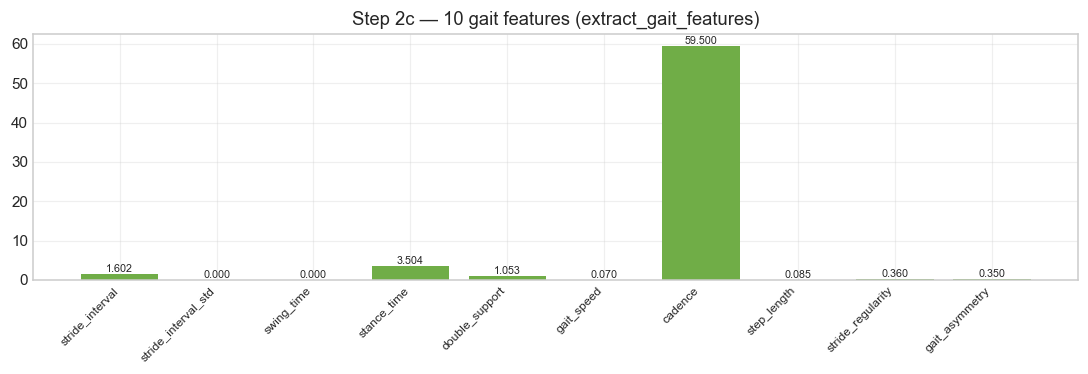

In [28]:
import contextlib
import io

import cv2

from common.video_processing import extract_gait_features, get_feature_names as gait_video_feature_names

gv = resolve_gait_demo_video(NOTEBOOK_SAMPLES)
if gv is not None:
    cap = cv2.VideoCapture(str(gv))
    motion_series = []
    prev = None
    fc = 0
    while fc < 300:
        ret, frame = cap.read()
        if not ret:
            break
        fc += 1
        g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        g = cv2.GaussianBlur(g, (21, 21), 0)
        if prev is not None:
            fd = cv2.absdiff(prev, g)
            _, th = cv2.threshold(fd, 25, 255, cv2.THRESH_BINARY)
            motion_series.append(float(np.sum(th) / (255 * th.size)))
        prev = g
    cap.release()
    if motion_series:
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(motion_series, color="#70ad47", lw=1)
        ax.set_xlabel("Frame pair index")
        ax.set_ylabel("Normalized motion (OpenCV)")
        ax.set_title("Step 2c — motion proxy over time (aligned with gait extraction)")
        plt.tight_layout()
        plt.show()
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        try:
            gt = extract_gait_features(str(gv))
        except Exception as ex:
            gt = None
            print("Gait extraction error:", ex)
    _log = buf.getvalue()
    if _log.strip():
        print(_log[:2000] + ("…" if len(_log) > 2000 else ""))
    if gt:
        gnames = gait_video_feature_names()
        gvals = [gt[k] for k in gnames]
        fig, ax = plt.subplots(figsize=(10, 3.5))
        bars = ax.bar(gnames, gvals, color="#70ad47")
        ax.set_xticklabels(gnames, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"Step 2c — {len(gnames)} gait features (extract_gait_features)")
        for bar, v in zip(bars, gvals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
            )
        plt.tight_layout()
        plt.show()
else:
    print("No gait video in notebooks/sample.")


## Step 3 — Tabular EDA

**HNR** by class, **N_speech × N_speech** speech correlation heatmap (N_speech = len of YAML `speech_features`), and **distributions by class**. If handwriting/gait arrays are non-zero, **per-column std** (exploratory; rows aligned by index per project contract).


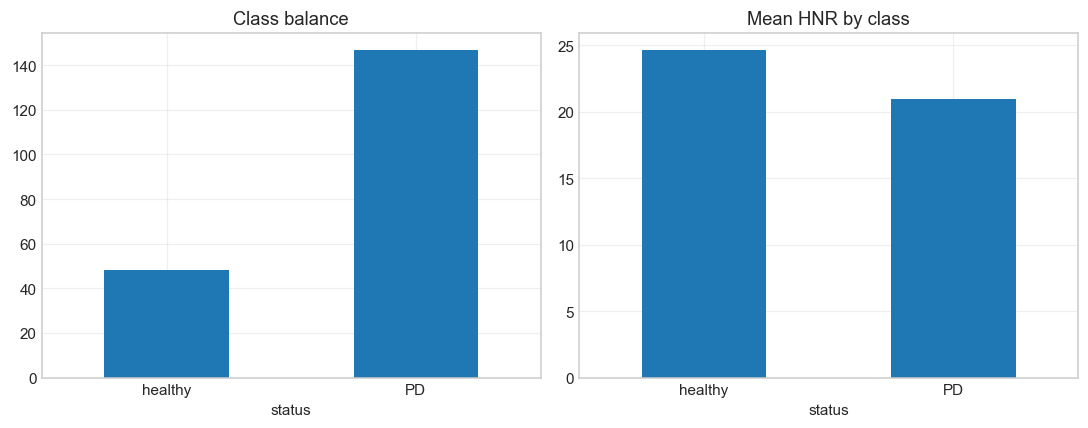

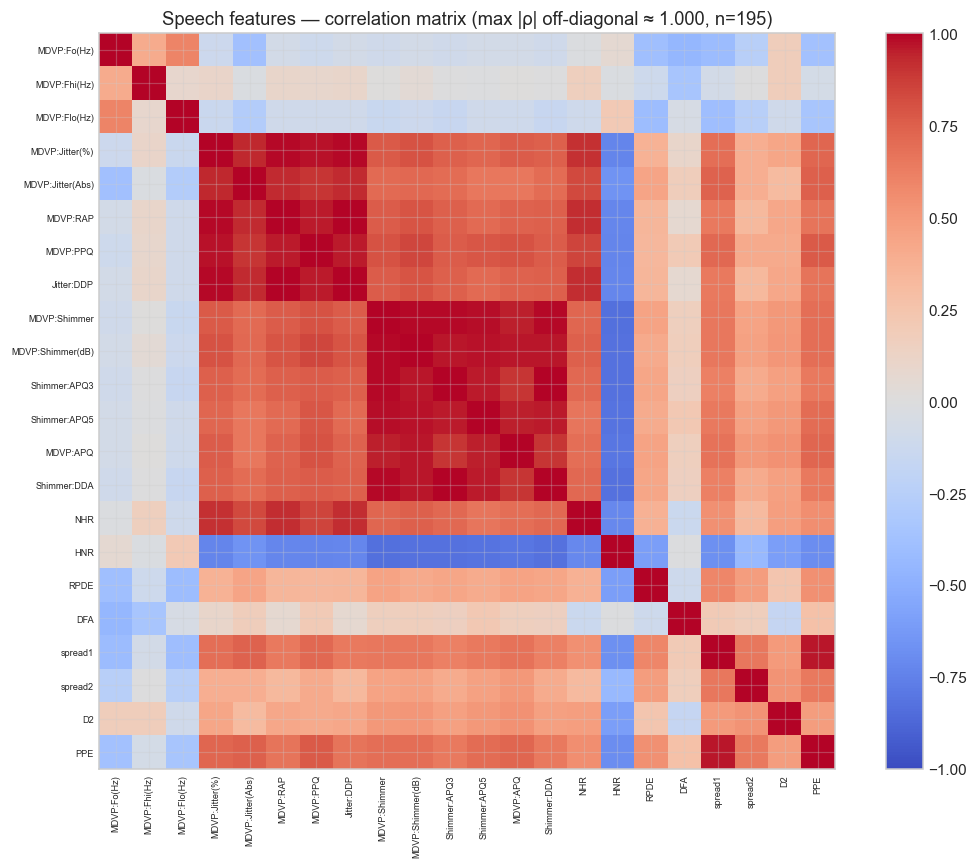

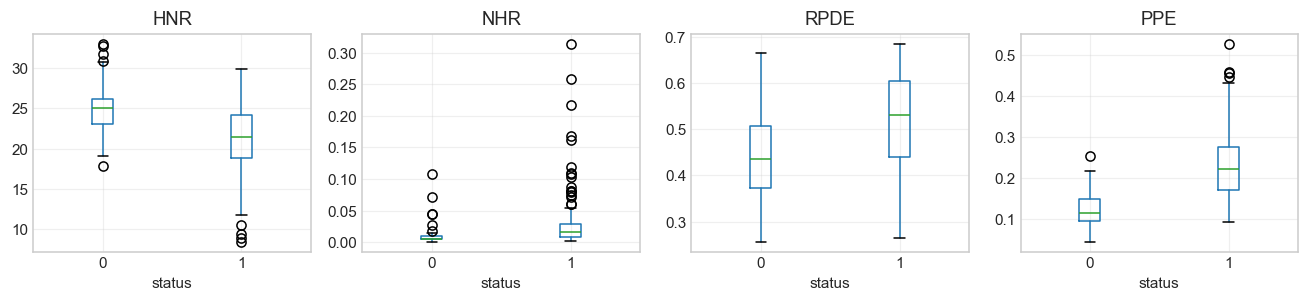

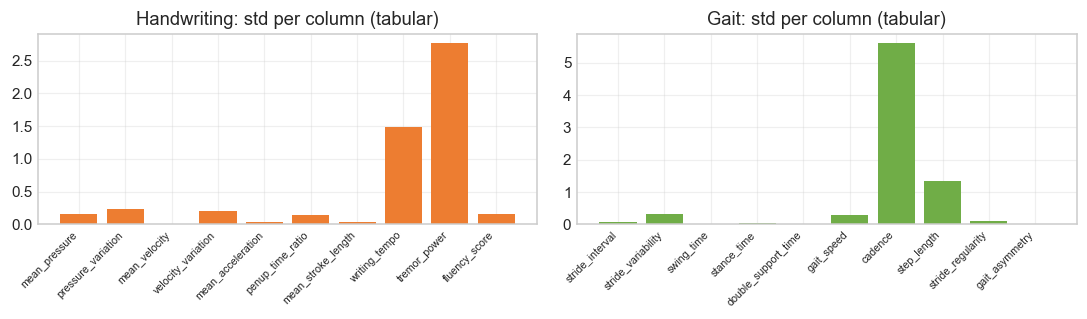

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
lc = str(MFC["label_column"])
df_speech[lc].value_counts().sort_index().plot(kind="bar", ax=ax[0], title="Class balance")
ax[0].set_xticklabels(["healthy", "PD"], rotation=0)
df_speech.groupby(lc)["HNR"].mean().plot(kind="bar", ax=ax[1], title="Mean HNR by class")
ax[1].set_xticklabels(["healthy", "PD"], rotation=0)
plt.tight_layout()
plt.show()

corr = df_speech[SPEECH_FEATURE_NAMES].corr()
_c = corr.values
_mask = ~np.eye(_c.shape[0], dtype=bool)
_max_off = float(np.nanmax(np.abs(_c[_mask]))) if _mask.any() else 0.0
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(_c, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(SPEECH_FEATURE_NAMES)))
ax.set_yticks(range(len(SPEECH_FEATURE_NAMES)))
ax.set_xticklabels(SPEECH_FEATURE_NAMES, rotation=90, fontsize=6)
ax.set_yticklabels(SPEECH_FEATURE_NAMES, fontsize=6)
ax.set_title(
    f"Speech features — correlation matrix (max |ρ| off-diagonal ≈ {_max_off:.3f}, n={len(df_speech)})",
)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

feats_4 = ["HNR", "NHR", "RPDE", "PPE"]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, col in zip(axes, feats_4):
    df_speech.boxplot(column=col, by=lc, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("status")
plt.suptitle("")
plt.tight_layout()
plt.show()

if np.abs(hw_X).sum() > 1e-9 or np.abs(gait_X).sum() > 1e-9:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].bar(range(len(HANDWRITING_FEATURE_NAMES)), np.std(hw_X, axis=0), color="#ed7d31")
    ax[0].set_xticks(range(len(HANDWRITING_FEATURE_NAMES)))
    ax[0].set_xticklabels(HANDWRITING_FEATURE_NAMES, rotation=45, ha="right", fontsize=7)
    ax[0].set_title("Handwriting: std per column (tabular)")
    ax[1].bar(range(len(GAIT_FEATURE_NAMES)), np.std(gait_X, axis=0), color="#70ad47")
    ax[1].set_xticks(range(len(GAIT_FEATURE_NAMES)))
    ax[1].set_xticklabels(GAIT_FEATURE_NAMES, rotation=45, ha="right", fontsize=7)
    ax[1].set_title("Gait: std per column (tabular)")
    plt.tight_layout()
    plt.show()


## Step 4 — SE-ResNet **1D** encoders (`MultimodalPDNet`)

Three separate PyTorch modules (same class, different input width). Sizes **N_speech / N_hw / N_gait** match `config/multimodal_features.yaml` (here: loaded from `SPEECH_FEATURE_NAMES` etc. in memory).

- **`model.speech_encoder`** — `ModalitySEResNet1D(N_speech → 64)`
- **`model.handwriting_encoder`** — `ModalitySEResNet1D(N_hw → 64)`
- **`model.gait_encoder`** — `ModalitySEResNet1D(N_gait → 64)`

Each: **Stem** `Conv1d(1→32)` → **Residual SE Block 1** (32→32) → **Residual SE Block 2** (32→64) → **GAP** → **Linear(64→64)** embedding.

Weights: `models/multimodal_pdnet.pt` when present (`python train_dl.py`).


No multimodal_pdnet.pt — using random weights (structure demo only).
Total parameters: 106,634 | trainable: 106,634
speech_encoder: ModalitySEResNet1D | in_features: 22
handwriting_encoder: ModalitySEResNet1D | in_features: 10
gait_encoder: ModalitySEResNet1D | in_features: 10


,stage,shape
0,input,"[1, 1, 22]"
1,after stem (initial),"[1, 32, 22]"
2,after block1,"32 ch, same L"
3,after block2,"64 ch, same L"
4,after GAP,"[1, 64]"
5,embedding,"[1, 64]"


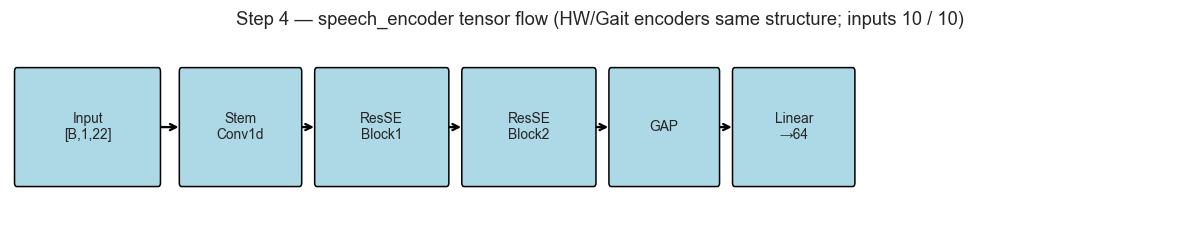

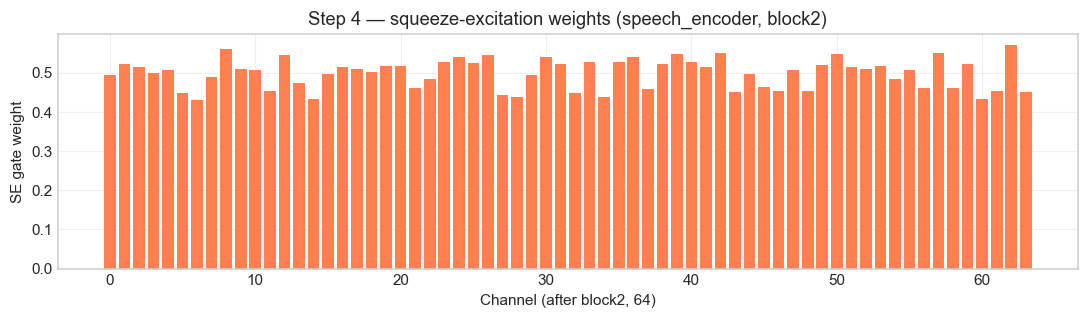

In [30]:
import matplotlib.patches as mpatches
import torch
from dl_models.data import (
    GAIT_FEATURE_NAMES,
    HANDWRITING_FEATURE_NAMES,
    SPEECH_FEATURE_NAMES,
)
from dl_models.algorithm import MultimodalPDNet

device = "cuda" if torch.cuda.is_available() else "cpu"
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"

_ns = len(SPEECH_FEATURE_NAMES)
_nh = len(HANDWRITING_FEATURE_NAMES)
_ng = len(GAIT_FEATURE_NAMES)
model = MultimodalPDNet(
    speech_features=_ns,
    handwriting_features=_nh,
    gait_features=_ng,
)
pt_path = MODELS / "multimodal_pdnet.pt"
if pt_path.is_file():
    state = torch.load(pt_path, map_location=device, weights_only=True)
    try:
        model.load_state_dict(state)
        print("Loaded weights from", pt_path)
    except Exception as _e:
        print("Checkpoint incompatible with current N_speech/N_hw/N_gait — demo with random weights:", _e)
else:
    print("No multimodal_pdnet.pt — using random weights (structure demo only).")
model.to(device)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", f"{n_params:,}", "| trainable:", f"{n_train:,}")
print("speech_encoder:", type(model.speech_encoder).__name__, "| in_features:", model.speech_encoder.num_features)
print("handwriting_encoder:", type(model.handwriting_encoder).__name__, "| in_features:", model.handwriting_encoder.num_features)
print("gait_encoder:", type(model.gait_encoder).__name__, "| in_features:", model.gait_encoder.num_features)

# Shape trail (speech branch) — manual stages + full forward for SE weights
with torch.no_grad():
    x0 = torch.zeros(1, _ns, device=device)
    x_in = x0.unsqueeze(1)
    h = model.speech_encoder.initial(x_in)
    stem_shape = list(h.shape)
    h, _ = model.speech_encoder.block1(h)
    h, _ = model.speech_encoder.block2(h)
    pooled = model.speech_encoder.gap(h).squeeze(-1)
    emb, s_info = model.speech_encoder(x0)

rows = [
    ("input", list(x_in.shape)),
    ("after stem (initial)", stem_shape),
    ("after block1", "32 ch, same L"),
    ("after block2", "64 ch, same L"),
    ("after GAP", list(pooled.shape)),
    ("embedding", list(emb.shape)),
]
display(pd.DataFrame(rows, columns=["stage", "shape"]))

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis("off")
boxes = [
    (0.05, 0.2, 1.2, 0.6, f"Input\n[B,1,{_ns}]"),
    (1.45, 0.2, 1.0, 0.6, "Stem\nConv1d"),
    (2.6, 0.2, 1.1, 0.6, "ResSE\nBlock1"),
    (3.85, 0.2, 1.1, 0.6, "ResSE\nBlock2"),
    (5.1, 0.2, 0.9, 0.6, "GAP"),
    (6.15, 0.2, 1.0, 0.6, "Linear\n→64"),
]
for bx, by, bw, bh, blab in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((bx, by), bw, bh, boxstyle="round,pad=0.02", ec="black", fc="lightblue"))
    ax.text(bx + bw / 2, by + bh / 2, blab, ha="center", va="center", fontsize=9)
for i in range(len(boxes) - 1):
    xa = boxes[i][0] + boxes[i][2]
    xb = boxes[i + 1][0]
    ax.annotate("", xy=(xb, 0.5), xytext=(xa, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_title(
    f"Step 4 — speech_encoder tensor flow (HW/Gait encoders same structure; inputs {_nh} / {_ng})",
)
plt.tight_layout()
plt.show()

# SE channel weights (block2), speech encoder
w2 = s_info["se_weights_2"].squeeze(0).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(np.arange(len(w2)), w2, color="coral")
ax.set_xlabel("Channel (after block2, 64)")
ax.set_ylabel("SE gate weight")
ax.set_title("Step 4 — squeeze-excitation weights (speech_encoder, block2)")
plt.tight_layout()
plt.show()


### Step 4b — Runtime, project paths, and training artifacts

Torch version, device, checkpoint/scaler presence, **paths to config & outputs**, **`dl_model_metrics.json`** summary, **loss curves** from JSON (when present), and previews of **saved PNGs** from `python train_dl.py`.


In [31]:
print("torch:", torch.__version__, "| device:", device)
print("multimodal_pdnet.pt:", pt_path.is_file(), "| dl_scalers.joblib:", (MODELS / "dl_scalers.joblib").is_file())

_proj_rows = [
    {"component": "Tabular data (raw_dir)", "path": str(RAW)},
    {"component": "Feature spec (YAML)", "path": str(FEATURE_SPEC_PATH)},
    {"component": "Train config", "path": str(ROOT / "config" / "project.yaml")},
    {"component": "Saved model", "path": str(pt_path)},
    {"component": "Metrics JSON", "path": str(MODELS / "dl_model_metrics.json")},
    {"component": "Training curves PNG", "path": str(MODELS / "dl_training_curves.png")},
    {"component": "ROC curve PNG", "path": str(MODELS / "dl_roc_curve.png")},
    {"component": "Confusion matrix PNG", "path": str(MODELS / "dl_confusion_matrix.png")},
]
display(pd.DataFrame(_proj_rows))

_metrics_path = MODELS / "dl_model_metrics.json"
if _metrics_path.is_file():
    with open(_metrics_path) as _mf:
        _met = json.load(_mf)
    _rows_m = []
    for k in (
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_roc_auc",
        "total_params",
        "trainable_params",
        "epochs_trained",
        "best_val_loss",
        "elapsed_seconds",
    ):
        if k in _met:
            _rows_m.append({"metric": k, "value": _met[k]})
    if "input_dims" in _met:
        for kk, vv in _met["input_dims"].items():
            _rows_m.append({"metric": f"input_dims.{kk}", "value": vv})
    display(pd.DataFrame(_rows_m))

    tl = _met.get("train_loss_history") or []
    vl = _met.get("val_loss_history") or []
    if tl and vl and len(tl) == len(vl):
        fig, ax = plt.subplots(figsize=(9, 4.5))
        epochs_x = np.arange(1, len(tl) + 1)
        ax.plot(epochs_x, tl, label="train loss", marker="o", markersize=3, linewidth=1.2)
        ax.plot(epochs_x, vl, label="val loss", marker="s", markersize=3, linewidth=1.2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("BCE loss")
        ax.set_title("Training / validation loss (from dl_model_metrics.json)")
        ax.legend()
        ax.set_xticks(epochs_x if len(epochs_x) <= 15 else epochs_x[:: max(1, len(epochs_x) // 12)])
        plt.tight_layout()
        plt.show()
        print(
            "Final epoch train loss:", f"{tl[-1]:.6f}",
            "| val loss:", f"{vl[-1]:.6f}",
            "| epochs:", len(tl),
        )
else:
    print("No dl_model_metrics.json yet — run: python train_dl.py")

for _png_name, _title in [
    ("dl_training_curves.png", "Saved training curves (file)"),
    ("dl_roc_curve.png", "Test ROC (file)"),
    ("dl_confusion_matrix.png", "Test confusion matrix (file)"),
]:
    _pp = MODELS / _png_name
    if _pp.is_file():
        img = plt.imread(_pp)
        plt.figure(figsize=(10, 4.2))
        plt.imshow(img)
        plt.axis("off")
        plt.title(_title)
        plt.tight_layout()
        plt.show()


torch: 2.11.0 | device: mps
multimodal_pdnet.pt: False | dl_scalers.joblib: False


,component,path
0,Tabular data (raw_dir),/Users/jenishs/Parkinson/data/raw
1,Feature spec (YAML),/Users/jenishs/Parkinson/config/multimodal_fea...
2,Train config,/Users/jenishs/Parkinson/config/project.yaml
3,Saved model,/Users/jenishs/Parkinson/models/multimodal_pdn...
4,Metrics JSON,/Users/jenishs/Parkinson/models/dl_model_metri...
5,Training curves PNG,/Users/jenishs/Parkinson/models/dl_training_cu...
6,ROC curve PNG,/Users/jenishs/Parkinson/models/dl_roc_curve.png
7,Confusion matrix PNG,/Users/jenishs/Parkinson/models/dl_confusion_m...


No dl_model_metrics.json yet — run: python train_dl.py


## Step 4c — Real-time feature extraction (inference path)

The tensors fed to **`MultimodalPDNet`** below are built **now** from files on disk:

1. **Speech:** `extract_speech_features` → vector in **`speech_features`** YAML order (same as UCI CSV columns).
2. **Handwriting:** `extract_handwriting_features` → remapped to **`handwriting_features`** CSV order (image keys differ slightly from CSV headers; see mapping in code).
3. **Gait:** `extract_gait_features` → remapped to **`gait_features`** CSV order (e.g. `stride_interval_std` → `stride_variability`).

**Requirements:** at least one resolved WAV (see `ordered_speech_demo_paths`), one image under `notebooks/sample/`, and one video. If anything is missing, the next cell raises with paths to add.

This is the same **production-style** path as uploading files to the web app: extract → scale (if `dl_scalers.joblib` exists) → model.

In [32]:
import contextlib
import io
from pathlib import Path
from typing import List, Optional

from common.audio_processing import extract_speech_features, features_dict_to_array as speech_features_to_list
from common.image_processing import extract_handwriting_features
from common.video_processing import extract_gait_features


def _first_existing_file(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p is not None and Path(p).is_file():
            return Path(p)
    return None


def _handwriting_image_dict_to_training_row(d: dict) -> np.ndarray:
    """Align image extractor output to YAML `handwriting_features` / CSV column order."""
    m = {
        "mean_pressure": d["mean_pressure"],
        "pressure_variation": d["std_pressure"],
        "mean_velocity": d["mean_velocity"],
        "velocity_variation": d["std_velocity"],
        "mean_acceleration": d["mean_acceleration"],
        "penup_time_ratio": d["pen_up_time"],
        "mean_stroke_length": d["stroke_length"],
        "writing_tempo": d["writing_tempo"],
        "tremor_power": d["tremor_frequency"],
        "fluency_score": d["fluency_score"],
    }
    return np.array([m[k] for k in HANDWRITING_FEATURE_NAMES], dtype=np.float64)


def _gait_video_dict_to_training_row(d: dict) -> np.ndarray:
    """Align video extractor output to YAML `gait_features` / CSV column order."""
    m = {
        "stride_interval": d["stride_interval"],
        "stride_variability": d["stride_interval_std"],
        "swing_time": d["swing_time"],
        "stance_time": d["stance_time"],
        "double_support_time": d["double_support"],
        "gait_speed": d["gait_speed"],
        "cadence": d["cadence"],
        "step_length": d["step_length"],
        "stride_regularity": d["stride_regularity"],
        "gait_asymmetry": d["gait_asymmetry"],
    }
    return np.array([m[k] for k in GAIT_FEATURE_NAMES], dtype=np.float64)


path_speech = _first_existing_file(ordered_speech_demo_paths(NOTEBOOK_SAMPLES, ROOT))
path_hw = resolve_handwriting_demo_path(NOTEBOOK_SAMPLES)
path_gait = resolve_gait_demo_video(NOTEBOOK_SAMPLES)

need = []
if path_speech is None:
    need.append("speech: add a .wav under notebooks/sample/ or data/examples/speech/")
if path_hw is None:
    need.append("handwriting: add an image under notebooks/sample/")
if path_gait is None:
    need.append("gait: add a video under notebooks/sample/")
if need:
    raise FileNotFoundError("Real-time multimodal inference requires:\n  " + "\n  ".join(need))

print("Real-time extraction — speech:", path_speech)
print("Real-time extraction — handwriting:", path_hw)
print("Real-time extraction — gait:", path_gait)

_spd = extract_speech_features(str(path_speech))
FEATURES_RT_SPEECH = np.array(speech_features_to_list(_spd), dtype=np.float64).reshape(1, -1)

_hwd = extract_handwriting_features(str(path_hw))
FEATURES_RT_HW = _handwriting_image_dict_to_training_row(_hwd).reshape(1, -1)

_buf_g = io.StringIO()
with contextlib.redirect_stdout(_buf_g):
    _gvd = extract_gait_features(str(path_gait))
FEATURES_RT_GAIT = _gait_video_dict_to_training_row(_gvd).reshape(1, -1)

assert FEATURES_RT_SPEECH.shape[1] == len(SPEECH_FEATURE_NAMES)
assert FEATURES_RT_HW.shape[1] == len(HANDWRITING_FEATURE_NAMES)
assert FEATURES_RT_GAIT.shape[1] == len(GAIT_FEATURE_NAMES)

print(
    "Built batch [1, N] — speech", FEATURES_RT_SPEECH.shape[1],
    "handwriting", FEATURES_RT_HW.shape[1],
    "gait", FEATURES_RT_GAIT.shape[1],
)
display(pd.DataFrame({"feature": SPEECH_FEATURE_NAMES, "value": FEATURES_RT_SPEECH.ravel()}))
display(pd.DataFrame({"feature": HANDWRITING_FEATURE_NAMES, "value": FEATURES_RT_HW.ravel()}))
display(pd.DataFrame({"feature": GAIT_FEATURE_NAMES, "value": FEATURES_RT_GAIT.ravel()}))

Real-time extraction — speech: /Users/jenishs/Parkinson/notebooks/sample/parkinson_example.wav
Real-time extraction — handwriting: /Users/jenishs/Parkinson/notebooks/sample/Handwriting.jpg
Real-time extraction — gait: /Users/jenishs/Parkinson/notebooks/sample/WhatsApp Video 2026-04-07 at 9.09.28 PM.mp4
Built batch [1, N] — speech 22 handwriting 10 gait 10


,feature,value
0,MDVP:Fo(Hz),185.303738
1,MDVP:Fhi(Hz),197.666856
2,MDVP:Flo(Hz),172.743135
3,MDVP:Jitter(%),0.579940
4,MDVP:Jitter(Abs),0.000031
5,MDVP:RAP,0.002434
6,MDVP:PPQ,0.002564
7,Jitter:DDP,0.007302
8,MDVP:Shimmer,0.030319
9,MDVP:Shimmer(dB),0.268322


,feature,value
0,mean_pressure,0.299688
1,pressure_variation,0.150855
2,mean_velocity,2.850656
3,velocity_variation,0.925328
4,mean_acceleration,1.425328
5,penup_time_ratio,0.400000
6,mean_stroke_length,128.395000
7,writing_tempo,1.100000
8,tremor_power,8.000000
9,fluency_score,0.610393


,feature,value
0,stride_interval,1.601600
1,stride_variability,0.000000
2,swing_time,0.000000
3,stance_time,3.503860
4,double_support_time,1.052531
5,gait_speed,0.069741
6,cadence,59.500000
7,step_length,0.085397
8,stride_regularity,0.360000
9,gait_asymmetry,0.350000


## Step 5 — Attention fusion (weighted sum of modality embeddings)

Uses **`FEATURES_RT_SPEECH`**, **`FEATURES_RT_HW`**, **`FEATURES_RT_GAIT`** from **Step 4c** (real-time extractors), not CSV rows. **Speech / Handwriting / Gait** → **[B,64]** embeddings → **softmax** attention → **weighted fusion** → **[B,64]** for the classifier.


No dl_scalers.joblib — using raw feature scales.
Encoder embeddings [B,64]: (1, 64) (1, 64) (1, 64)


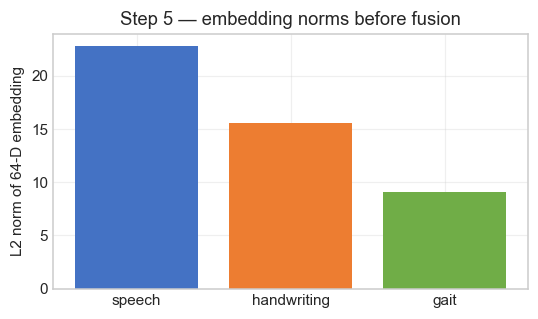

,modality,attention_softmax_weight
0,speech,0.455162
1,handwriting,0.189937
2,gait,0.354901


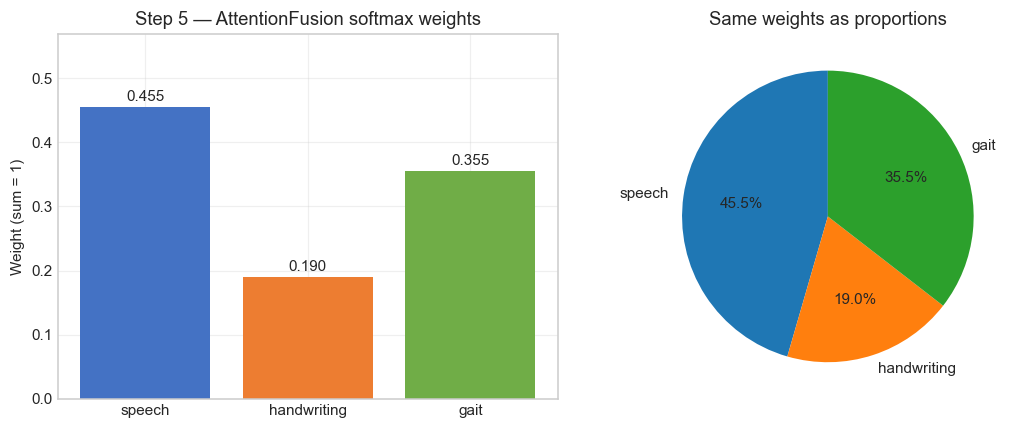

In [33]:
import joblib

# Real-time feature matrices from Step 4c (extracted from WAV / image / video just above).
s = FEATURES_RT_SPEECH.astype(np.float32)
h = FEATURES_RT_HW.astype(np.float32)
g = FEATURES_RT_GAIT.astype(np.float32)

scalers_path = MODELS / "dl_scalers.joblib"
if scalers_path.is_file():
    scalers = joblib.load(scalers_path)
    s = scalers["speech"].transform(s)
    h = scalers["handwriting"].transform(h)
    g = scalers["gait"].transform(g)
    print("Applied dl_scalers.joblib")
else:
    print("No dl_scalers.joblib — using raw feature scales.")

s_t = torch.tensor(s, dtype=torch.float32, device=device)
h_t = torch.tensor(h, dtype=torch.float32, device=device)
g_t = torch.tensor(g, dtype=torch.float32, device=device)

with torch.no_grad():
    s_emb, _ = model.speech_encoder(s_t)
    h_emb, _ = model.handwriting_encoder(h_t)
    g_emb, _ = model.gait_encoder(g_t)
print("Encoder embeddings [B,64]:", tuple(s_emb.shape), tuple(h_emb.shape), tuple(g_emb.shape))

norms = [
    float(torch.norm(s_emb).cpu()),
    float(torch.norm(h_emb).cpu()),
    float(torch.norm(g_emb).cpu()),
]
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["speech", "handwriting", "gait"], norms, color=["#4472c4", "#ed7d31", "#70ad47"])
ax.set_ylabel("L2 norm of 64-D embedding")
ax.set_title("Step 5 — embedding norms before fusion")
plt.tight_layout()
plt.show()

with torch.no_grad():
    stacked = torch.stack([s_emb, h_emb, g_emb], dim=1)
    fused_for_classifier, attn_w = model.fusion(stacked)
    out = model(s_t, h_t, g_t)

attn = attn_w.squeeze(0).cpu().numpy()
labels = ["speech", "handwriting", "gait"]
display(pd.DataFrame({"modality": labels, "attention_softmax_weight": attn}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, attn, color=["#4472c4", "#ed7d31", "#70ad47"])
axes[0].set_ylabel("Weight (sum = 1)")
axes[0].set_title("Step 5 — AttentionFusion softmax weights")
axes[0].set_ylim(0, max(0.15, float(attn.max()) * 1.25))
for i, v in enumerate(attn):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
axes[1].pie(attn, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Same weights as proportions")
plt.tight_layout()
plt.show()

if pt_path.is_file():
    try:
        # API uses |scaled-input| bars (see DLDetector), not Grad-CAM.
        abs_s = s_t.squeeze(0).abs().cpu().numpy()
        sp = abs_s / (abs_s.sum() + 1e-12)
        top = np.argsort(sp)[::-1][:8]
        print("|speech input| share (top-8 indices):", top.tolist())
        print("  normalized:", np.round(sp[top], 4).tolist())
    except Exception as _demo_exc:
        print("Demo skipped:", _demo_exc)


## Step 6 — Dense classifier (diagram: **64 → 32 → 1**)

`DenseClassifier`: **Linear(64,32) → ReLU → Dropout → Linear(32,1)** → **logit** (then **sigmoid** in the full forward).


Step 6 — DenseClassifier modules:
 DenseClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
logit full forward: 0.506784 | manual path: 0.506784


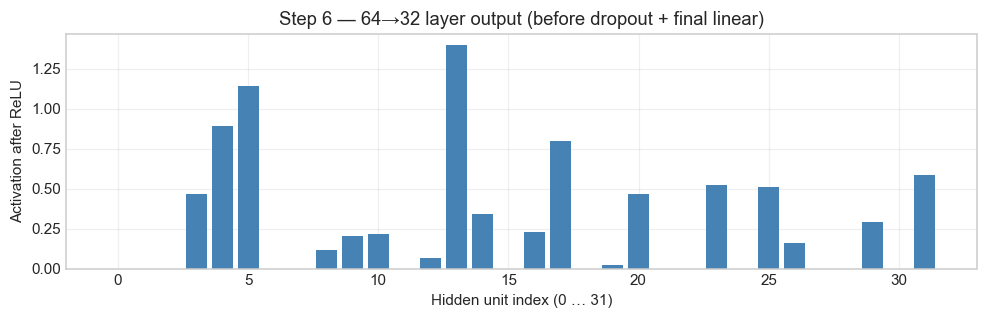

In [34]:
with torch.no_grad():
    fused = fused_for_classifier
    lin1 = model.classifier.net[0](fused)
    hidden = model.classifier.net[1](lin1)
    dropped = model.classifier.net[2](hidden)
    logit_manual = model.classifier.net[3](dropped)

print("Step 6 — DenseClassifier modules:\n", model.classifier)
print(f"logit full forward: {out['logit'].item():.6f} | manual path: {logit_manual.item():.6f}")

hvec = hidden.squeeze(0).detach().cpu().numpy()
plt.figure(figsize=(9, 3))
plt.bar(np.arange(len(hvec)), hvec, color="steelblue")
plt.xlabel("Hidden unit index (0 … 31)")
plt.ylabel("Activation after ReLU")
plt.title("Step 6 — 64→32 layer output (before dropout + final linear)")
plt.tight_layout()
plt.show()


## Step 7 — Output (detection)

**Sigmoid(logit) → P(PD)**. Threshold **0.5** → **Healthy** vs **Parkinson's** (demo only; not clinical).


Step 7 — P(PD) = sigmoid(logit): 0.6241
Step 7 — predicted class: Parkinson's | ground truth: N/A (demo media — no single CSV label for this clip trio)


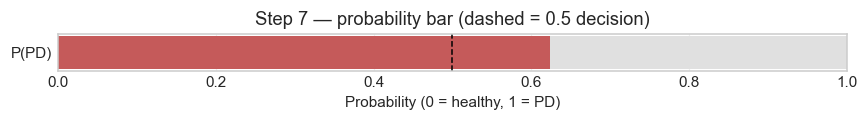

In [35]:
prob = out["probability"].item()
print("Step 7 — P(PD) = sigmoid(logit):", round(prob, 4))
print(
    "Step 7 — predicted class:",
    "Parkinson's" if prob >= 0.5 else "Healthy",
    "| ground truth: N/A (demo media — no single CSV label for this clip trio)",
)

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.barh([0], [prob], color="#c55a5a" if prob >= 0.5 else "#5a8fc5", height=0.5)
ax.barh([0], [1.0 - prob], left=[prob], color="#e0e0e0", height=0.5)
ax.set_xlim(0, 1)
ax.set_yticks([0])
ax.set_yticklabels(["P(PD)"])
ax.set_xlabel("Probability (0 = healthy, 1 = PD)")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("Step 7 — probability bar (dashed = 0.5 decision)")
plt.tight_layout()
plt.show()


**Next:** dataset paths and columns — [README.md](../README.md) and [config/multimodal_features.yaml](../config/multimodal_features.yaml). Web app flow — same README.
